In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Logistic Regression

#what the type of this Model ?

Logistic Regression is a supervised machine learning algorithm used mainly for binary classification problems

#What the output of this model ?

where the target variable has two possible outcomes (e.g., Yes/No, 0/1, Pass/Fail

#As per the name of the model "Logistic Regression" , Is that Model Regression ?

Logistic Regression is actually a classification algorithm, not a regression one

#How this Model Work ?

Instead of predicting a continuous value like Linear Regression, Logistic Regression predicts a probability between 0 and 1 using a special function called the sigmoid (logistic) function.

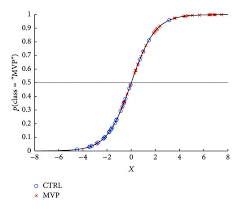

#How Logistic Regression Works ?

############################

Example of Cancer

#############################

1. y=wx+b
2. pass the value through the sigmoid function to convert this value to probability
3. if the probability us greater than threshold , the model predict class 1 , else class 0

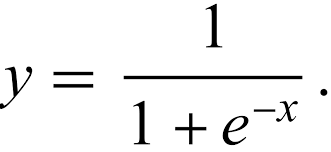

Sigmoid Function Convert any real number into the range of 0 , 1

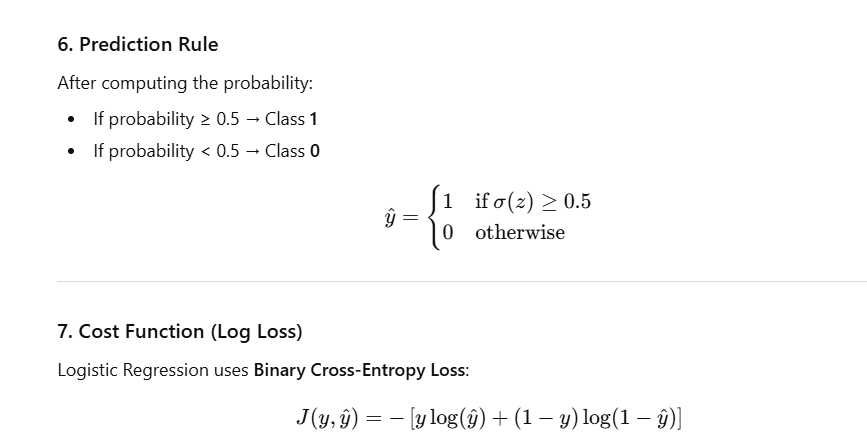

#Come To see the Sigmoid function alone

In [ ]:
import numpy as np

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# Example usage
z_values = np.array([-2,-1,0,1,2])
sigmoid_values = sigmoid(z_values)

print(sigmoid_values)

[0.11920292 0.26894142 0.5        0.73105858 0.88079708]


Build a Logistic Regression model to predict whether a tumor is Malignant (1) or Benign (0) based on medical measurements

In [ ]:
df=pd.read_csv("/content/breast_cancer.csv")

In [ ]:
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [ ]:
df.shape

(569, 31)

split the data x ,y

In [ ]:
x=df.drop('target',axis=1)
y=df['target']

In [ ]:
x.head(2)

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.8,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.6,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.9,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.8,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902


In [ ]:
y

,target
0,0
1,0
2,0
3,0
4,0
...,...
564,0
565,0
566,0
567,0


In [ ]:
print(y.value_counts())

target
1    357
0    212
Name: count, dtype: int64


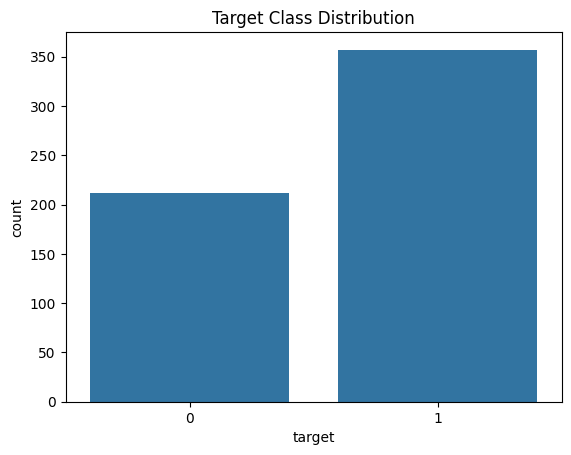

In [ ]:
sns.countplot(x=y)
plt.title("Target Class Distribution")
plt.show()

In [ ]:
print(f'Number of people who are Malignant: {(y == 1).sum()}')

Number of people who are Malignant: 357


In [ ]:
print(f'Number of people who Benign: {(y==0).sum()}')

Number of people who Benign: 212


In [ ]:
print(f'The precentage of people who Malignant is : {round (    ( ((y == 1).sum()) / ((y == 0).sum()+ (y == 1).sum()))* 100  ,   2   )} % ')

The precentage of people who Malignant is : 62.74 % 


In [ ]:
print(f'The precentage of people who Benign is :{round( ( ((y == 0).sum()) / ((y == 0).sum()+ (y == 1).sum()) )*100  , 2 ) } %')

The precentage of people who Benign is :37.26 %


In [ ]:
x.isnull().sum().sum()

np.int64(0)

In [ ]:
y.isnull().sum().sum()

np.int64(0)

#split the data train , test

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(x_train)
X_test_scaled = scaler.transform(x_test)

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
y_pred = model.predict(X_test_scaled)

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9824561403508771


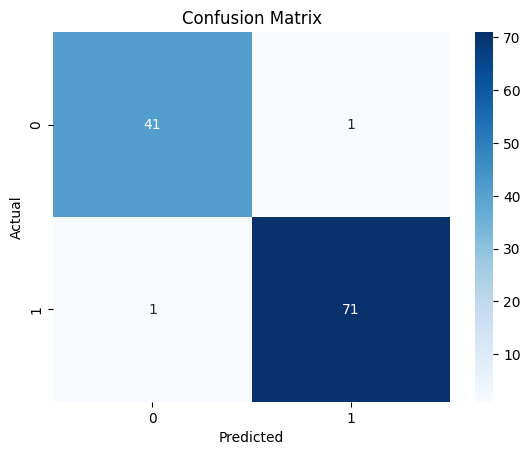

In [ ]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()
